# 01. Random Forest PoC — 200-User 5G Diversity Dataset

This notebook provides an initial **Proof-of-Concept (PoC)** on the 5G NR 3.0 GHz **200-User Dataset** (`99,589 samples`).

### Starter Configuration:
- **Model:** `RandomForestRegressor` (Fast baseline, multi-output Cartesian targets).
- **History Depth:** `h=1` Hybrid Mode (`current absolute snapshot + 1 delta lag`).
- **Data Partitioning:** **Unseen User Split** (160 Training Users vs. 40 Unseen Test Users).
- **Signal Noise Model:** 4° Gaussian AoA noise + 5° angle quantization.

In [1]:
import sys, os, time, warnings, json, math, datetime, glob
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

NOTEBOOK_DIR = Path(os.getcwd())
PROJECT_ROOT = NOTEBOOK_DIR
for _ in range(10):
    if (PROJECT_ROOT / 'results' / 'grid_localization' / 'grid_25x25').exists():
        break
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        break
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT / 'experiments' / '09_grid_localization' / 'src' / 'python'))

from pipelines.multi_user_200_pipeline import load_200_users, make_unseen_user_split
from pipelines.multi_user_pipeline_regression import _read_bs_position_3d, build_history_features, get_feature_cols

RUN_TIMESTAMP = datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
OUT_DIR = PROJECT_ROOT / 'results' / 'notebook_experiments' / 'multi_user_poc' / f'rf_poc_{RUN_TIMESTAMP}'
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'Output directory: {OUT_DIR}')

Output directory: D:\gilad\projects\Academy\CSI-Location\results\notebook_experiments\multi_user_poc\rf_poc_2026-07-24_19-32-32


## Global Settings & Hyperparameters

In [2]:
# ── Global Configuration Constants ─────────────────────────────────────
N_JOBS              = 4        # Max CPU workers
TRAIN_USER_RATIO    = 0.80     # 80% Train Users (160 Users) / 20% Test Users (40 Users)
H_TARGET            = 1        # History depth (h=1 proven RF sweet spot)
FEATURE_MODE        = 'hybrid' # Hybrid mode: current abs + 1 delta lag
SEED                = 42       # Random seed
N_ESTIMATORS        = 100      # Number of RF trees
MAX_DEPTH           = 15       # Tree max depth

np.random.seed(SEED)
print(f'Global Config: N_JOBS={N_JOBS} | Train User Ratio={TRAIN_USER_RATIO*100:.0f}% | h={H_TARGET} ({FEATURE_MODE})')

Global Config: N_JOBS=4 | Train User Ratio=80% | h=1 (hybrid)


## Load 200-User 5G NR Dataset & Apply Noise Model

In [3]:
data_base = PROJECT_ROOT / 'results' / 'grid_localization' / 'grid_25x25'
dirs = sorted(list(data_base.glob('sim_data_200users_*')))
if not dirs:
    raise FileNotFoundError('No sim_data_200users_* dataset directories found!')
DATA_DIR = dirs[-1]
print(f'Loading 200-User dataset from: {DATA_DIR}')

df_raw = load_200_users(DATA_DIR)
print(f'Loaded {len(df_raw):,} records across {len(df_raw["user_id"].unique())} diverse mobile users.')

bs_pos = np.array(_read_bs_position_3d(DATA_DIR))
ue_xyz = np.column_stack([df_raw['x_pos'], df_raw['y_pos'], df_raw['ue_height']])
delta  = ue_xyz - bs_pos
df_raw['target_x'], df_raw['target_y'], df_raw['target_z'] = delta[:,0], delta[:,1], delta[:,2]

# Apply standard 4° AoA Noise + 5° Angle Quantization
AOA_NOISE_STD_DEG = 4.0
AOA_QUANT_STEP_DEG = 5.0
mask_ant = df_raw['n_antennas'] > 1
rng_noise = np.random.RandomState(SEED)
df_raw.loc[mask_ant, 'aoa_azimuth'] = df_raw.loc[mask_ant, 'aoa_azimuth'].values + (AOA_NOISE_STD_DEG * rng_noise.randn(mask_ant.sum())).astype(np.float32)
df_raw.loc[mask_ant, 'aoa_elevation'] = df_raw.loc[mask_ant, 'aoa_elevation'].values + (AOA_NOISE_STD_DEG * rng_noise.randn(mask_ant.sum())).astype(np.float32)
df_raw.loc[mask_ant, 'aoa_azimuth'] = np.round(df_raw.loc[mask_ant, 'aoa_azimuth'] / AOA_QUANT_STEP_DEG) * AOA_QUANT_STEP_DEG
df_raw.loc[mask_ant, 'aoa_elevation'] = np.round(df_raw.loc[mask_ant, 'aoa_elevation'] / AOA_QUANT_STEP_DEG) * AOA_QUANT_STEP_DEG
df_raw.loc[~mask_ant, ['aoa_azimuth', 'aoa_elevation']] = 0.0

print('Applied 4° AoA noise + 5° quantization to multi-antenna UEs.')

Loading 200-User dataset from: D:\gilad\projects\Academy\CSI-Location\results\grid_localization\grid_25x25\sim_data_200users_2026-07-24_18-09-51


Loaded 99,589 records across 200 diverse mobile users.
Applied 4° AoA noise + 5° quantization to multi-antenna UEs.


## Construct History Features ($h=1$ Hybrid) & Unseen User Split

In [4]:
print(f'Building transition history features (h={H_TARGET}, mode={FEATURE_MODE})...')
df_feat = build_history_features(df_raw, h=H_TARGET, extra_cols=['device'], include_aoa=True, feature_mode=FEATURE_MODE)
feat_cols = get_feature_cols(h=H_TARGET, extra_cols=['device'], include_aoa=True, feature_mode=FEATURE_MODE)
target_cols = ['target_x', 'target_y', 'target_z']

df_feat[feat_cols] = df_feat[feat_cols].fillna(0.0)

# Unseen User Split: 80% Train Users / 20% Unseen Test Users
df_split, train_users, test_users = make_unseen_user_split(df_feat, train_ratio=TRAIN_USER_RATIO, seed=SEED)
df_train = df_split[df_split['split']=='train'].reset_index(drop=True)
df_test  = df_split[df_split['split']=='test'].reset_index(drop=True)

print(f'Unseen User Partition: {len(train_users)} Train Users ({len(df_train):,} samples) | {len(test_users)} Unseen Test Users ({len(df_test):,} samples)')
print(f'Input Features ({len(feat_cols)}): {feat_cols}')

Building transition history features (h=1, mode=hybrid)...


Unseen User Partition: 160 Train Users (79,226 samples) | 40 Unseen Test Users (20,163 samples)
Input Features (11): ['rss_lag0', 'sinr_lag0', 'aoa_az_lag0', 'aoa_el_lag0', 'rss_delta_lag0', 'sinr_delta_lag0', 'aoa_az_delta_lag0', 'aoa_el_delta_lag0', 'feat_n_antennas', 'feat_antenna_gain_db', 'feat_ue_height']


## Train Random Forest Regressor

In [5]:
X_tr = df_train[feat_cols].values
y_tr = df_train[target_cols].values
X_te = df_test[feat_cols].values
y_te = df_test[target_cols].values

print(f'Training RandomForestRegressor (n_estimators={N_ESTIMATORS}, max_depth={MAX_DEPTH}, n_jobs={N_JOBS})...')
t0 = time.time()
rf = RandomForestRegressor(n_estimators=N_ESTIMATORS, max_depth=MAX_DEPTH, min_samples_leaf=5, n_jobs=N_JOBS, random_state=SEED)
rf.fit(X_tr, y_tr)
t_fit = time.time() - t0
print(f'Random Forest trained successfully in {t_fit:.2f} seconds!')

Training RandomForestRegressor (n_estimators=100, max_depth=15, n_jobs=4)...


Random Forest trained successfully in 17.36 seconds!


## Evaluate Model Performance on Unseen Test Users

In [6]:
preds = rf.predict(X_te)
errors_3d = np.linalg.norm(preds - y_te, axis=1)
mae_3d    = np.mean(errors_3d)
mae_x     = mean_absolute_error(y_te[:, 0], preds[:, 0])
mae_y     = mean_absolute_error(y_te[:, 1], preds[:, 1])
mae_z     = mean_absolute_error(y_te[:, 2], preds[:, 2])
p50       = np.percentile(errors_3d, 50)
p90       = np.percentile(errors_3d, 90)

print('=== RANDOM FOREST PoC BENCHMARK (UNSEEN 40 TEST USERS) ===')
print(f'3D Position MAE:                  {mae_3d:.3f} meters')
print(f'X-Axis MAE:                       {mae_x:.3f} meters')
print(f'Y-Axis MAE:                       {mae_y:.3f} meters')
print(f'Z-Axis MAE:                       {mae_z:.3f} meters')
print(f'50th Percentile (Median Error):   {p50:.3f} meters')
print(f'90th Percentile Error:           {p90:.3f} meters')

=== RANDOM FOREST PoC BENCHMARK (UNSEEN 40 TEST USERS) ===
3D Position MAE:                  26.607 meters
X-Axis MAE:                       16.973 meters
Y-Axis MAE:                       17.922 meters
Z-Axis MAE:                       0.125 meters
50th Percentile (Median Error):   22.134 meters
90th Percentile Error:           55.230 meters


## Visualizing Trajectories of Unseen Test Users

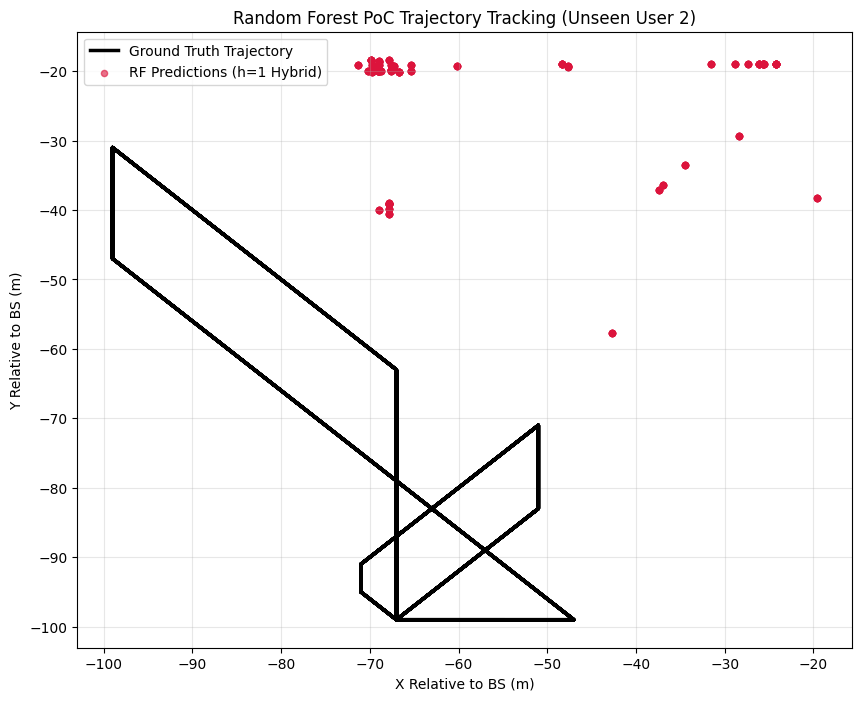

In [7]:
sample_test_user = sorted(list(test_users))[0]
udf = df_test[df_test['user_id']==sample_test_user].sort_values('step_index').reset_index(drop=True)
X_u = udf[feat_cols].values
y_u = udf[target_cols].values
p_u = rf.predict(X_u)

plt.figure(figsize=(10, 8))
plt.plot(y_u[:, 0], y_u[:, 1], 'k-', lw=2.5, label='Ground Truth Trajectory')
plt.scatter(p_u[:, 0], p_u[:, 1], color='crimson', alpha=0.6, s=20, label='RF Predictions (h=1 Hybrid)')
plt.xlabel('X Relative to BS (m)'); plt.ylabel('Y Relative to BS (m)')
plt.title(f'Random Forest PoC Trajectory Tracking (Unseen User {sample_test_user})')
plt.legend(); plt.grid(alpha=0.3)
plt.savefig(OUT_DIR / 'rf_poc_trajectory.png', dpi=150, bbox_inches='tight')
plt.show()